# Customer Churn Data Preprocessing and Feature Engineering



In [1]:
import pandas as pd
import numpy as np
import json
import sqlite3
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

## Part A: Fundamentals

### 1. What is Data Analysis?
Data analysis is the process of collecting, cleaning, transforming, and interpreting data to discover useful information, identify patterns, and support decision-making. It helps convert raw data into meaningful insights that can be used for solving business problems.

### 2. Steps to Plan a Data Science Project
1. Understand the business problem.
2. Define the project objective.
3. Collect data from multiple sources.
4. Clean and preprocess the data.
5. Perform exploratory data analysis.
6. Engineer useful features.
7. Build and evaluate machine learning models.
8. Interpret results and communicate findings.
9. Deploy or present the final solution.

### 3. Machine Learning Problem Statement
This project is a binary classification problem. The aim is to predict whether a customer will churn or not based on demographic features, purchase behavior, support activity, and engagement-related variables.

### 4. What are Tensors?
A tensor is a mathematical object used to represent data in multiple dimensions.

- A scalar is a 0-dimensional tensor.
- A vector is a 1-dimensional tensor.
- A matrix is a 2-dimensional tensor.
- Higher-dimensional arrays are also tensors.

Tensors are important in machine learning because they are used to represent inputs, outputs, features, and model parameters in a structured numerical form.

In [2]:
scalar = np.array(5)
vector = np.array([1, 2, 3])
matrix = np.array([[1, 2], [3, 4]])
tensor_3d = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

print("Scalar:", scalar, "Shape:", scalar.shape)
print("Vector:", vector, "Shape:", vector.shape)
print("Matrix:\n", matrix, "Shape:", matrix.shape)
print("3D Tensor:\n", tensor_3d, "Shape:", tensor_3d.shape)

Scalar: 5 Shape: ()
Vector: [1 2 3] Shape: (3,)
Matrix:
 [[1 2]
 [3 4]] Shape: (2, 2)
3D Tensor:
 [[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]] Shape: (2, 2, 2)


## Part B: Data Acquisition
In this section, data is imported from CSV, JSON, SQL, and API sources.

In [3]:
# Load CSV file
customers = pd.read_csv("data/customers.csv")
customers.head()

,customer_id,age,gender,income,churn
0,C001,24,Female,32000,0
1,C002,29,Male,41000,1
2,C003,35,Female,52000,0
3,C004,41,Male,61000,1
4,C005,27,Female,39000,0


In [4]:
# Load JSON file
with open("data/purchases.json", "r") as file:
    purchases_data = json.load(file)

purchases = pd.DataFrame(purchases_data)
purchases.head()

,customer_id,purchase_amount,total_orders,tenure_months
0,C001,1200,4,8
1,C002,900,2,6
2,C003,2400,6,14
3,C004,1100,3,10
4,C005,1800,5,12


In [5]:
# Load SQL data
conn = sqlite3.connect("data/support.db")
support = pd.read_sql("SELECT * FROM support_table", conn)
support.head()

,customer_id,complaint_count,refund_requests,avg_resolution_days,support_channel
0,C001,1,0,2.0,Email
1,C002,3,1,4.0,Phone
2,C003,1,0,1.5,Chat
3,C004,4,2,5.0,Phone
4,C005,2,0,2.5,Email


In [6]:
# Fetch data from API
url = "https://dummyjson.com/users"
response = requests.get(url)
api_json = response.json()

# Adjust this part if your API response format is different
api_data = pd.DataFrame(api_json["users"])
api_data.head()

,customer_id,app_sessions,email_click_rate,city,segment
0,C001,18,0.21,Mumbai,Regular
1,C002,9,0.11,Delhi,At Risk
2,C003,24,0.28,Pune,Loyal
3,C004,12,0.14,Hyderabad,At Risk
4,C005,20,0.22,Chennai,Regular


In [7]:
print("Customers Data")
display(customers.head())

print("Purchases Data")
display(purchases.head())

print("Support Data")
display(support.head())

print("API Data")
display(api_data.head())

Customers Data


,customer_id,age,gender,income,churn
0,C001,24,Female,32000,0
1,C002,29,Male,41000,1
2,C003,35,Female,52000,0
3,C004,41,Male,61000,1
4,C005,27,Female,39000,0


Purchases Data


,customer_id,purchase_amount,total_orders,tenure_months
0,C001,1200,4,8
1,C002,900,2,6
2,C003,2400,6,14
3,C004,1100,3,10
4,C005,1800,5,12


Support Data


,customer_id,complaint_count,refund_requests,avg_resolution_days,support_channel
0,C001,1,0,2.0,Email
1,C002,3,1,4.0,Phone
2,C003,1,0,1.5,Chat
3,C004,4,2,5.0,Phone
4,C005,2,0,2.5,Email


API Data


,customer_id,app_sessions,email_click_rate,city,segment
0,C001,18,0.21,Mumbai,Regular
1,C002,9,0.11,Delhi,At Risk
2,C003,24,0.28,Pune,Loyal
3,C004,12,0.14,Hyderabad,At Risk
4,C005,20,0.22,Chennai,Regular


In [8]:
# Merge datasets using customer_id
# Replace the column names below if your dataset uses different names
df = customers.merge(purchases, on="customer_id", how="left")
df = df.merge(support, on="customer_id", how="left")

# If API data does not have customer_id, create or map it before merging
# Example: api_data = api_data.rename(columns={"id": "customer_id"})
if "customer_id" in api_data.columns:
    df = df.merge(api_data, on="customer_id", how="left")

df.head()

,customer_id,age,gender,income,churn,purchase_amount,total_orders,tenure_months,complaint_count,refund_requests,avg_resolution_days,support_channel,app_sessions,email_click_rate,city,segment
0,C001,24,Female,32000,0,1200,4,8,1,0,2.0,Email,18,0.21,Mumbai,Regular
1,C002,29,Male,41000,1,900,2,6,3,1,4.0,Phone,9,0.11,Delhi,At Risk
2,C003,35,Female,52000,0,2400,6,14,1,0,1.5,Chat,24,0.28,Pune,Loyal
3,C004,41,Male,61000,1,1100,3,10,4,2,5.0,Phone,12,0.14,Hyderabad,At Risk
4,C005,27,Female,39000,0,1800,5,12,2,0,2.5,Email,20,0.22,Chennai,Regular


## Part C: Data Understanding and Cleaning

In [9]:
df.head()

,customer_id,age,gender,income,churn,purchase_amount,total_orders,tenure_months,complaint_count,refund_requests,avg_resolution_days,support_channel,app_sessions,email_click_rate,city,segment
0,C001,24,Female,32000,0,1200,4,8,1,0,2.0,Email,18,0.21,Mumbai,Regular
1,C002,29,Male,41000,1,900,2,6,3,1,4.0,Phone,9,0.11,Delhi,At Risk
2,C003,35,Female,52000,0,2400,6,14,1,0,1.5,Chat,24,0.28,Pune,Loyal
3,C004,41,Male,61000,1,1100,3,10,4,2,5.0,Phone,12,0.14,Hyderabad,At Risk
4,C005,27,Female,39000,0,1800,5,12,2,0,2.5,Email,20,0.22,Chennai,Regular


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          20 non-null     object 
 1   age                  20 non-null     int64  
 2   gender               20 non-null     object 
 3   income               20 non-null     int64  
 4   churn                20 non-null     int64  
 5   purchase_amount      20 non-null     int64  
 6   total_orders         20 non-null     int64  
 7   tenure_months        20 non-null     int64  
 8   complaint_count      20 non-null     int64  
 9   refund_requests      20 non-null     int64  
 10  avg_resolution_days  20 non-null     float64
 11  support_channel      20 non-null     object 
 12  app_sessions         20 non-null     int64  
 13  email_click_rate     20 non-null     float64
 14  city                 20 non-null     object 
 15  segment              20 non-null     objec

In [11]:
df.describe(include="all")

,customer_id,age,gender,income,churn,purchase_amount,total_orders,tenure_months,complaint_count,refund_requests,avg_resolution_days,support_channel,app_sessions,email_click_rate,city,segment
count,20,20.000000,20,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20,20.000000,20.000000,20,20
unique,20,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,10,3
top,C001,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Phone,NaN,NaN,Mumbai,At Risk
freq,1,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,NaN,NaN,3,8
mean,NaN,35.250000,NaN,53400.000000,0.400000,1775.000000,4.600000,11.450000,2.050000,0.550000,2.890000,NaN,17.700000,0.207500,NaN,NaN
std,NaN,7.010331,NaN,13747.344241,0.502625,848.915717,2.280351,4.684521,1.571958,0.759155,1.483204,NaN,7.484018,0.085709,NaN,NaN
min,NaN,24.000000,NaN,32000.000000,0.000000,800.000000,2.000000,5.000000,0.000000,0.000000,1.000000,NaN,7.000000,0.090000,NaN,NaN
25%,NaN,29.750000,NaN,42500.000000,0.000000,1137.500000,3.000000,8.000000,1.000000,0.000000,1.775000,NaN,11.750000,0.137500,NaN,NaN
50%,NaN,34.500000,NaN,51500.000000,0.000000,1550.000000,4.000000,10.000000,1.500000,0.000000,2.300000,NaN,17.500000,0.205000,NaN,NaN
75%,NaN,40.250000,NaN,61750.000000,1.000000,2175.000000,6.000000,14.250000,3.250000,1.000000,4.275000,NaN,22.500000,0.265000,NaN,NaN


In [12]:
df.isnull().sum()

customer_id            0
age                    0
gender                 0
income                 0
churn                  0
purchase_amount        0
total_orders           0
tenure_months          0
complaint_count        0
refund_requests        0
avg_resolution_days    0
support_channel        0
app_sessions           0
email_click_rate       0
city                   0
segment                0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

### Initial Observations
- Write here what you found from `.head()`, `.info()`, `.describe()`, missing values, and duplicates.
- Mention which columns need cleaning, which have null values, and which data types look inconsistent.

In [14]:
# Handle missing values
# Replace these sample columns with your real numeric/categorical columns
numeric_columns = ["income", "purchase_amount", "total_orders", "tenure_months"]
categorical_columns = ["gender"]

# for column in numeric_columns:
#     if column in df.columns:
#         df[column] = pd.to_numeric(df[column], errors="coerce")
#         df[column].fillna(df[column].median(), inplace=True)

# for column in categorical_columns:
#     if column in df.columns:
#         df[column].fillna(df[column].mode()[0], inplace=True)

df.isnull().sum()

customer_id            0
age                    0
gender                 0
income                 0
churn                  0
purchase_amount        0
total_orders           0
tenure_months          0
complaint_count        0
refund_requests        0
avg_resolution_days    0
support_channel        0
app_sessions           0
email_click_rate       0
city                   0
segment                0
dtype: int64

In [15]:
# Correct inconsistent data types
for column in ["income", "purchase_amount", "total_orders", "tenure_months"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          20 non-null     object 
 1   age                  20 non-null     int64  
 2   gender               20 non-null     object 
 3   income               20 non-null     int64  
 4   churn                20 non-null     int64  
 5   purchase_amount      20 non-null     int64  
 6   total_orders         20 non-null     int64  
 7   tenure_months        20 non-null     int64  
 8   complaint_count      20 non-null     int64  
 9   refund_requests      20 non-null     int64  
 10  avg_resolution_days  20 non-null     float64
 11  support_channel      20 non-null     object 
 12  app_sessions         20 non-null     int64  
 13  email_click_rate     20 non-null     float64
 14  city                 20 non-null     object 
 15  segment              20 non-null     objec

In [16]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [17]:
# Drop irrelevant columns if needed
irrelevant_columns = ["unnecessary_column"]
df.drop(columns=irrelevant_columns, inplace=True, errors="ignore")
df.head()

,customer_id,age,gender,income,churn,purchase_amount,total_orders,tenure_months,complaint_count,refund_requests,avg_resolution_days,support_channel,app_sessions,email_click_rate,city,segment
0,C001,24,Female,32000,0,1200,4,8,1,0,2.0,Email,18,0.21,Mumbai,Regular
1,C002,29,Male,41000,1,900,2,6,3,1,4.0,Phone,9,0.11,Delhi,At Risk
2,C003,35,Female,52000,0,2400,6,14,1,0,1.5,Chat,24,0.28,Pune,Loyal
3,C004,41,Male,61000,1,1100,3,10,4,2,5.0,Phone,12,0.14,Hyderabad,At Risk
4,C005,27,Female,39000,0,1800,5,12,2,0,2.5,Email,20,0.22,Chennai,Regular


In [18]:
df.head()

,customer_id,age,gender,income,churn,purchase_amount,total_orders,tenure_months,complaint_count,refund_requests,avg_resolution_days,support_channel,app_sessions,email_click_rate,city,segment
0,C001,24,Female,32000,0,1200,4,8,1,0,2.0,Email,18,0.21,Mumbai,Regular
1,C002,29,Male,41000,1,900,2,6,3,1,4.0,Phone,9,0.11,Delhi,At Risk
2,C003,35,Female,52000,0,2400,6,14,1,0,1.5,Chat,24,0.28,Pune,Loyal
3,C004,41,Male,61000,1,1100,3,10,4,2,5.0,Phone,12,0.14,Hyderabad,At Risk
4,C005,27,Female,39000,0,1800,5,12,2,0,2.5,Email,20,0.22,Chennai,Regular


In [19]:
df.to_csv("data/final_cleaned_dataset.csv", index=False)
print("Final cleaned dataset saved successfully.")

Final cleaned dataset saved successfully.


## Part D: Exploratory Data Analysis (EDA)

### 1. Univariate Analysis

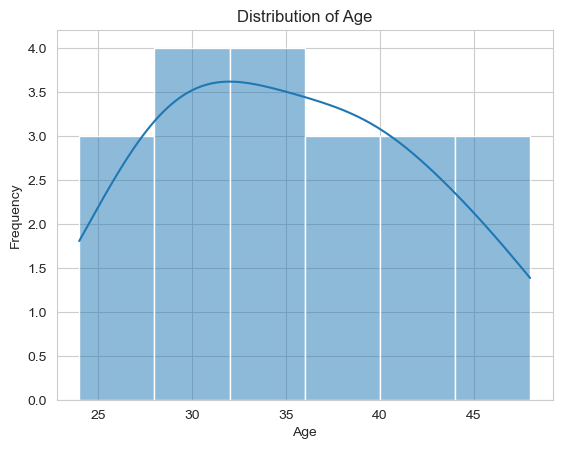

In [20]:
sns.histplot(df["age"], kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#### Interpretation of Age Distribution
Write 2 to 3 lines here about the spread, concentration, and skewness of the age data.

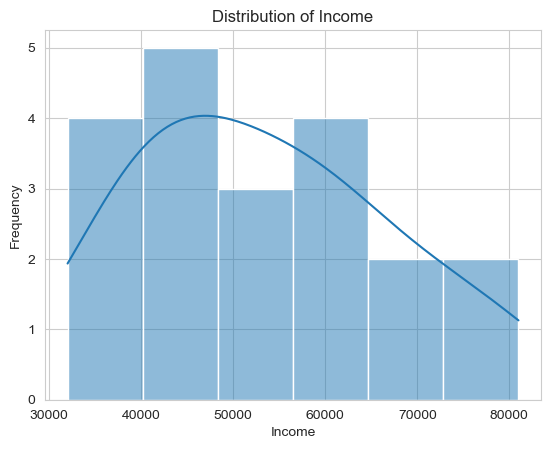

In [21]:
sns.histplot(df["income"], kde=True)
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

#### Interpretation of Income Distribution
Write 2 to 3 lines here about how income is distributed and whether it is skewed.

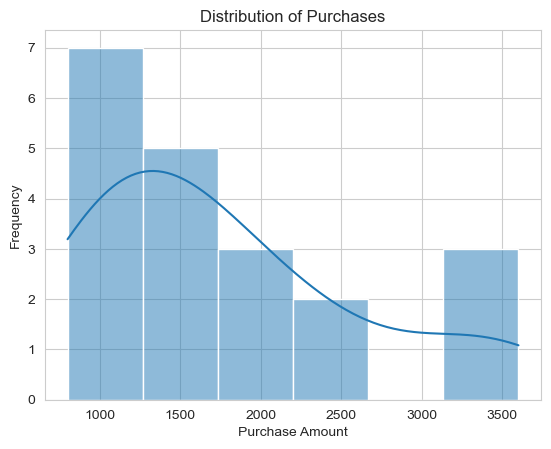

In [22]:
sns.histplot(df["purchase_amount"], kde=True)
plt.title("Distribution of Purchases")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

### 2. Bivariate Analysis

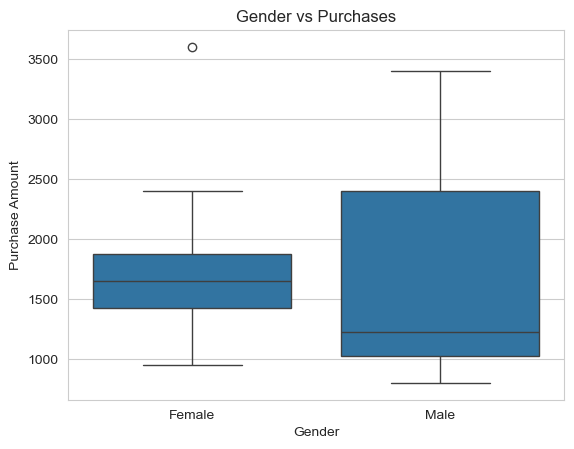

In [23]:
sns.boxplot(x="gender", y="purchase_amount", data=df)
plt.title("Gender vs Purchases")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount")
plt.show()

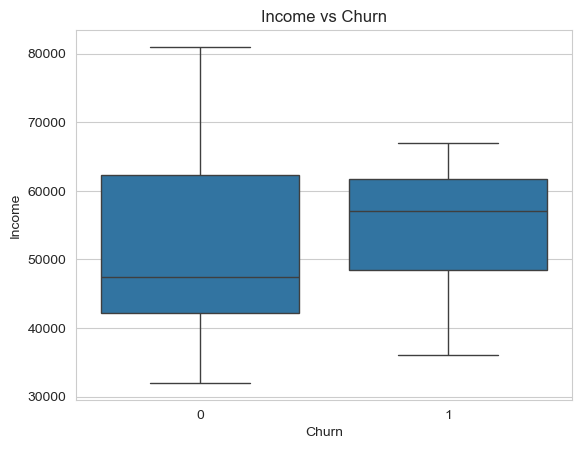

In [24]:
sns.boxplot(x="churn", y="income", data=df)
plt.title("Income vs Churn")
plt.xlabel("Churn")
plt.ylabel("Income")
plt.show()

### 3. Multivariate Analysis

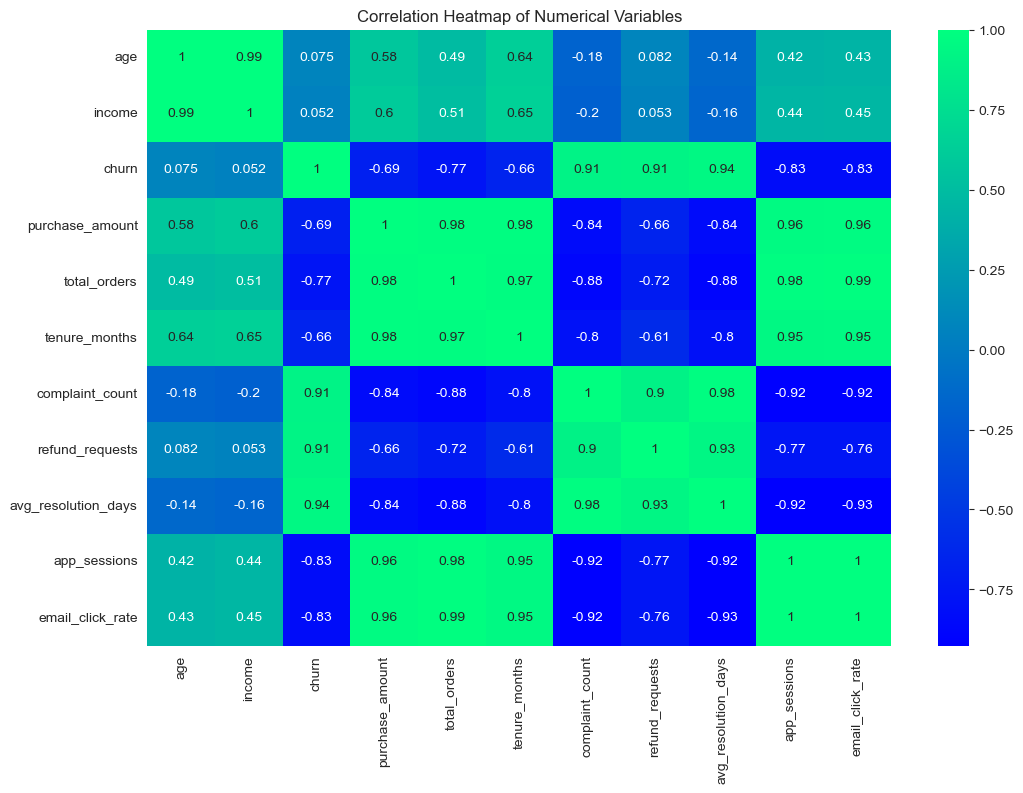

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="winter")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

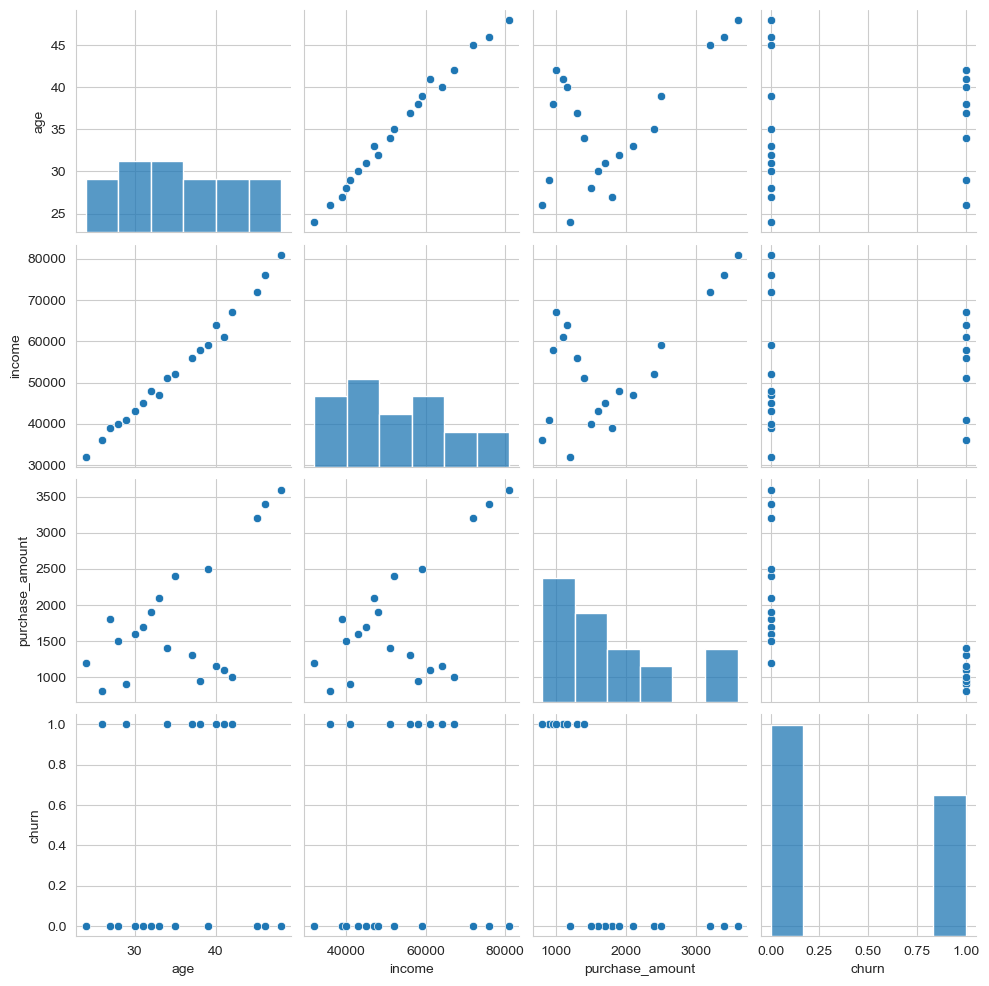

In [26]:
sns.pairplot(df[["age", "income", "purchase_amount", "churn"]])

plt.show()

## Part E: Data Profiling

In [27]:
profile = ProfileReport(df, title="Customer Churn Profiling Report", explorative=True)
profile.to_file("reports/profile_report.html")
print("Profile report generated successfully.")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 560.22it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profile report generated successfully.


### Summary of Profiling Report
The profiling report includes:
- missing values
- descriptive statistics
- correlations
- warnings about potential data quality issues

## Conclusion
In this project, customer data was collected from multiple sources, merged into a single dataset, cleaned, transformed, and analyzed. Feature engineering was applied to create useful variables for churn analysis. Exploratory data analysis and profiling helped identify patterns, relationships, and data quality issues. The final dataset is now ready for building a churn prediction model.

## Submission Files Included
- Jupyter Notebook (`.ipynb`)
- CSV file
- JSON file
- SQL database file
- Final cleaned dataset
- Profiling report (`.html`)
- Theory PDF
- README file